# R06 — Round Trends

**Goal:** See how our performance changes over rounds within a battle.

If we improve over rounds, our learning systems (VCS histograms, VGM gun selection)
are adapting. If we get worse, the opponent may be adapting to us faster.

In [1]:
import sys; sys.path.insert(0, '..')
from retrospective._retro_helpers import load_local_scores, add_opponent_names
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (16, 6)
plt.rcParams['figure.dpi'] = 100

scores = add_opponent_names(load_local_scores())
print(f'Loaded {len(scores):,} score rows')

Indexed 96 ticks.csv files across 6 distinct robots from 1 root(s).
Selected 6 robots × ~100 battles = 96 (battle, robot) pairs to load.


D:\robocode-autopilot\intuition\.venv\lib\site-packages\pandas\core\dtypes\astype.py:133: RuntimeWarning: overflow encountered in cast
  return arr.astype(dtype, copy=True)
D:\robocode-autopilot\intuition\.venv\lib\site-packages\pandas\core\dtypes\astype.py:133: RuntimeWarning: overflow encountered in cast
  return arr.astype(dtype, copy=True)


Loaded 96 scores.csv files → 3,360 rows × 17 cols, 6 robots (~0.6 MB)
Loaded 1,680 score rows


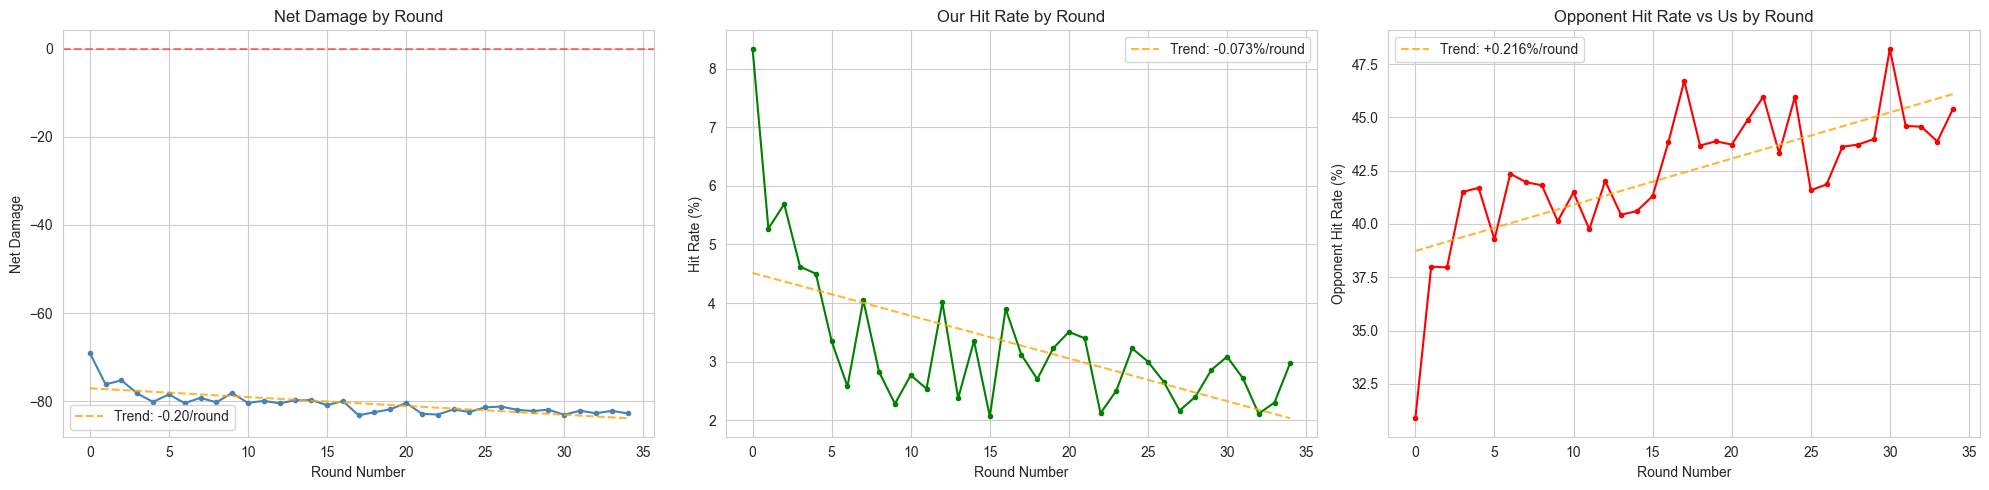

In [2]:
# Performance by round number (aggregated across all opponents)
round_stats = scores.groupby('round').agg(
    net_damage=('net_damage', 'mean'),
    our_hr=('our_hit_rate', 'mean'),
    opp_hr=('opponent_hit_rate', 'mean'),
    win_rate=('win_rate', 'mean'),
    count=('round', 'count'),
)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Net damage by round
ax = axes[0]
ax.plot(round_stats.index, round_stats['net_damage'], 'o-', color='steelblue', markersize=3)
ax.set_xlabel('Round Number')
ax.set_ylabel('Net Damage')
ax.set_title('Net Damage by Round')
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
z = np.polyfit(round_stats.index, round_stats['net_damage'], 1)
p = np.poly1d(z)
ax.plot(round_stats.index, p(round_stats.index), '--', color='orange', alpha=0.8,
        label=f'Trend: {z[0]:+.2f}/round')
ax.legend()

# Our hit rate by round
ax = axes[1]
ax.plot(round_stats.index, round_stats['our_hr'] * 100, 'o-', color='green', markersize=3)
ax.set_xlabel('Round Number')
ax.set_ylabel('Hit Rate (%)')
ax.set_title('Our Hit Rate by Round')
z = np.polyfit(round_stats.index, round_stats['our_hr'], 1)
p = np.poly1d(z)
ax.plot(round_stats.index, p(round_stats.index) * 100, '--', color='orange', alpha=0.8,
        label=f'Trend: {z[0]*100:+.3f}%/round')
ax.legend()

# Opponent hit rate by round
ax = axes[2]
ax.plot(round_stats.index, round_stats['opp_hr'] * 100, 'o-', color='red', markersize=3)
ax.set_xlabel('Round Number')
ax.set_ylabel('Opponent Hit Rate (%)')
ax.set_title('Opponent Hit Rate vs Us by Round')
z = np.polyfit(round_stats.index, round_stats['opp_hr'], 1)
p = np.poly1d(z)
ax.plot(round_stats.index, p(round_stats.index) * 100, '--', color='orange', alpha=0.8,
        label=f'Trend: {z[0]*100:+.3f}%/round')
ax.legend()

plt.tight_layout()
plt.show()

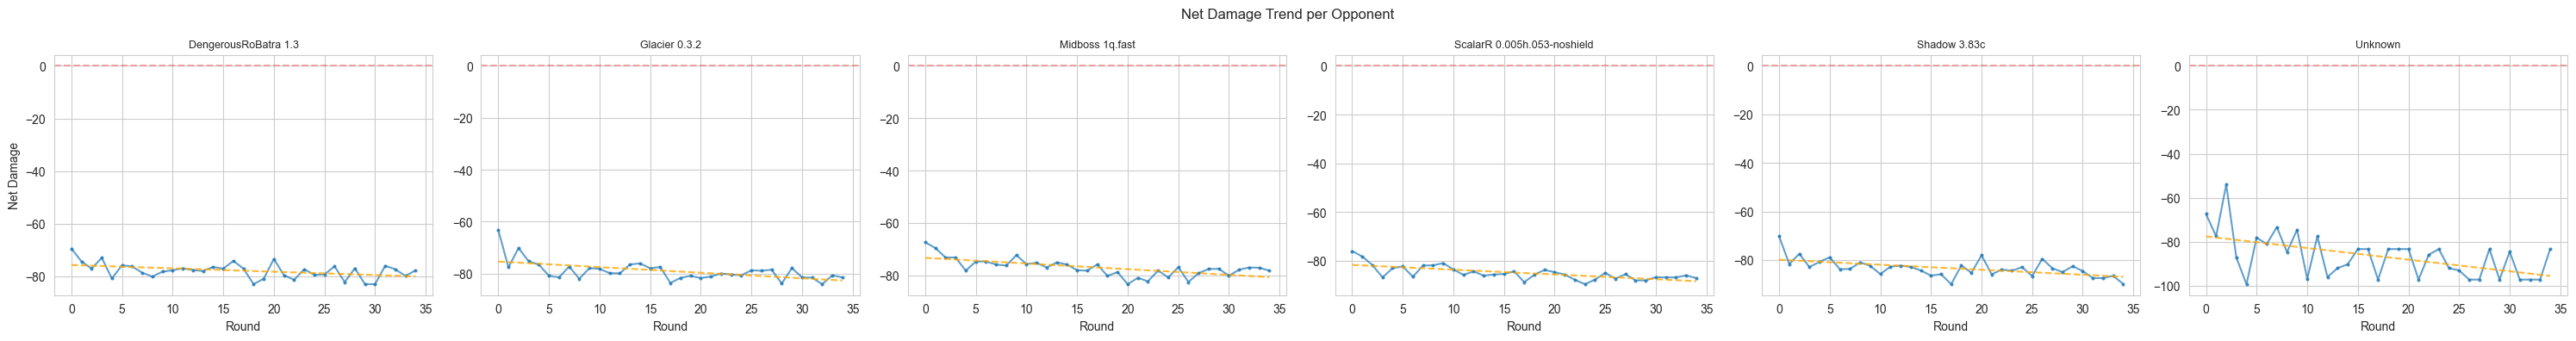

In [3]:
# Per-opponent round trends
opponents = scores['opponent_name'].unique()
n_opp = len(opponents)
fig, axes = plt.subplots(1, n_opp, figsize=(5*n_opp, 4), squeeze=False)

for i, opp in enumerate(sorted(opponents)):
    ax = axes[0, i]
    opp_data = scores[scores['opponent_name'] == opp].groupby('round')['net_damage'].mean()
    ax.plot(opp_data.index, opp_data.values, 'o-', markersize=2, alpha=0.7)
    ax.set_title(opp, fontsize=9)
    ax.set_xlabel('Round')
    if i == 0:
        ax.set_ylabel('Net Damage')
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.3)
    # Trend
    if len(opp_data) > 1:
        z = np.polyfit(opp_data.index, opp_data.values, 1)
        p = np.poly1d(z)
        ax.plot(opp_data.index, p(opp_data.index), '--', color='orange', alpha=0.8)

plt.suptitle('Net Damage Trend per Opponent', fontsize=12)
plt.tight_layout()
plt.show()